# 05. ベイズ線形回帰 — 回帰線にも不確実性を

## この章で分かること

- 線形回帰をベイズのフローに乗せる(係数 $w$ が「分布を持つ」)
- 事後分布・**信用バンド**(回帰関数の不確実性)と **予測バンド**(観測の不確実性)の違い
- データが増えると回帰線の束が締まっていく様子
- **Ridge 回帰 = 正規事前分布の MAP 推定** という正体

## 1. モデル

$$
y = X w + \epsilon
$$

$$
w \sim \mathcal{N}(0, \sigma_w^2 I), \qquad \epsilon \sim \mathcal{N}(0, \sigma^2 I)
$$

- **仮説**: データは直線(+ノイズ)で説明できる。係数 $w$ は未知
- **事前**: $w$ は 0 周りに分布($\sigma_w$ が「係数はこのくらいの大きさのはず」という信念)
- **事後**: 正規×正規の共役性(04 章)がそのまま多次元化して、閉形式で書けます:

$$
\Sigma_w = \left( \frac{X^\top X}{\sigma^2} + \frac{I}{\sigma_w^2} \right)^{-1},
\qquad
\mu_w = \Sigma_w \frac{X^\top y}{\sigma^2}
$$

事後も正規分布。つまり **「回帰線の確率分布」** が手に入ります。

```{admonition} 核心 — ひとことで
:class: tip
**ベイズ線形回帰は「回帰線そのものに確率分布を持たせる」。事後も正規で閉形式（正規×正規の多次元版）。**
信用バンド（関数の不確実性、データで消える）と予測バンド（観測ノイズ込み、消えない）を区別するのが肝。
そして **Ridge 回帰＝正規事前の MAP**（$\lambda=\sigma^2/\sigma_w^2$）— 正則化は事前分布の言い換えにすぎない。
```

In [1]:
# Shared setup.
import matplotlib.pyplot as plt
import numpy as np
import plotly.io as pio

from bayes_textbook import visualization as viz
from bayes_textbook.models import BayesianLinearRegression, ridge_solution

pio.renderers.default = "plotly_mimetype+notebook_connected"
rng = np.random.default_rng(42)
np.set_printoptions(precision=4, suppress=True)

# Synthetic data: y = 0.8 + 1.4 x + noise.
true_w = np.array([0.8, 1.4])
sigma_noise = 1.0
x_all = np.sort(rng.uniform(-3, 3, 60))
y_all = true_w[0] + true_w[1] * x_all + sigma_noise * rng.standard_normal(60)

## 2. 回帰線の「束」— 事後からのサンプル

事後分布から $w$ を引くたびに 1 本の回帰線が出ます。
データ点が少ない領域・端では線がばらけ、データの密な所では収束する —
**不確実性が場所によって違う** ことが一目で分かります。

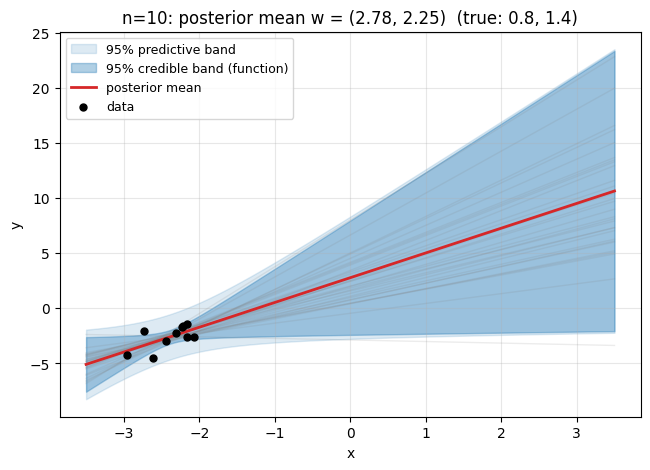

In [2]:
# Fit with n=10 points and draw the bundle of plausible regression lines.
n = 10
x, y = x_all[:n], y_all[:n]
X = np.column_stack([np.ones_like(x), x])
model = BayesianLinearRegression(sigma=sigma_noise, sigma_w=10.0).fit(X, y)

viz.plot_regression_uncertainty(x, y, model, x_grid=np.linspace(-3.5, 3.5, 120))
plt.title(f"n={n}: posterior mean w = ({model.w_mean[0]:.2f}, {model.w_mean[1]:.2f})  "
          f"(true: {true_w[0]}, {true_w[1]})")
plt.show()

2 種類のバンドの読み分けが重要です。

- **信用バンド(濃い)**: 回帰 **関数** $x^\top w$ の不確実性。データが増えると 0 に向かう。
- **予測バンド(薄い)**: 新しい **観測** $y_{\mathrm{new}}$ の不確実性。
  ノイズ $\sigma^2$ が足されるので、データが無限でも $\pm 1.96\sigma$ より狭くならない。

$$
\mathrm{Var}[y_{\mathrm{new}}] = \underbrace{x^\top \Sigma_w x}_{\text{weight uncertainty}} + \underbrace{\sigma^2}_{\text{noise}}
$$

(第 1 項が係数の不確実性、第 2 項が観測ノイズです。)

## 3. データが増えると束が締まる

$n$ を増やしながら同じ図を描きます(Plotly スライダー、静的 HTML でも動作)。
信用バンドだけが締まり、予測バンドはノイズの分だけ残ることに注目。

In [3]:
# Posterior mean line + credible band as n grows (slider).
x_grid = np.linspace(-3.5, 3.5, 100)
Xg = np.column_stack([np.ones_like(x_grid), x_grid])
frames = []
for n in [3, 5, 10, 20, 40, 60]:
    Xn = np.column_stack([np.ones(n), x_all[:n]])
    m = BayesianLinearRegression(sigma=sigma_noise, sigma_w=10.0).fit(Xn, y_all[:n])
    pred = m.predict(Xg)
    frames.append((f"{n}",
                   [("posterior mean", pred["mean"], None),
                    ("credible lo", pred["cred_lo"], "dot"),
                    ("credible hi", pred["cred_hi"], "dot"),
                    ("true line", true_w[0] + true_w[1] * x_grid, "dash")]))
fig = viz.plotly_curve_slider(x_grid, frames, slider_name="n data points",
                              title="credible band tightens as data accumulates")
fig.show()

### インタラクティブ(JupyterLab のみ)

データ数と事前の強さ($\sigma_w$)を同時に動かすデモです。

In [4]:
# Interactive (JupyterLab only): n and prior strength sliders.
from bayes_textbook.widgets import interactive_bayesian_regression

interactive_bayesian_regression()

interactive(children=(IntSlider(value=10, description='n_points', max=80, min=2), FloatSlider(value=1.0, descr…

<function bayes_textbook.widgets.interactive_bayesian_regression.<locals>.draw(n_points, log10_sigma_w)>

## 4. Ridge 回帰との関係 — 正則化の正体は事前分布

事後分布の最大点(MAP)を求めると:

$$
\hat{w}_{\mathrm{MAP}} = \arg\max_w \log p(w \mid y)
= \arg\min_w \left[ \|y - Xw\|^2 + \frac{\sigma^2}{\sigma_w^2} \|w\|^2 \right]
$$

これは **Ridge 回帰そのもの**($\lambda = \sigma^2 / \sigma_w^2$)。

> Ridge の罰則項 = 「係数は 0 の近くにいるはず」という正規事前分布の対数

機械学習の正則化はベイズの事前分布の言い換えだった、という本書屈指の「つながる瞬間」です
(neural_net 教材 04 章の weight decay も同じ構図)。

In [5]:
# The posterior mean IS the ridge solution with lambda = sigma^2 / sigma_w^2.
sigma_w = 2.0
lam = sigma_noise**2 / sigma_w**2
X60 = np.column_stack([np.ones_like(x_all), x_all])
blr = BayesianLinearRegression(sigma=sigma_noise, sigma_w=sigma_w).fit(X60, y_all)
ridge_w = ridge_solution(X60, y_all, lam)
print(f"Bayes posterior mean : {blr.w_mean}")
print(f"Ridge (lambda={lam}) : {ridge_w}")
print(f"max |diff| = {np.abs(blr.w_mean - ridge_w).max():.2e}")

Bayes posterior mean : [0.596  1.3528]
Ridge (lambda=0.25) : [0.596  1.3528]
max |diff| = 2.22e-16


## 5. 事前を強くすると係数が縮む

$\sigma_w$ を小さく(= 事前を強く)すると、係数は 0 へ引っ張られます。
Ridge の $\lambda$ を大きくするのと同じことです。

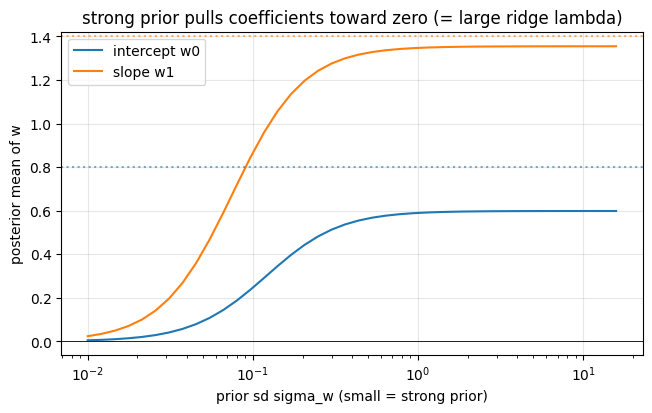

In [6]:
# Shrinkage path: posterior mean of each coefficient vs prior strength.
sigma_ws = np.logspace(-2, 1.2, 40)
w_paths = np.array([
    BayesianLinearRegression(sigma=sigma_noise, sigma_w=sw).fit(X60, y_all).w_mean
    for sw in sigma_ws
])
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.semilogx(sigma_ws, w_paths[:, 0], label="intercept w0")
ax.semilogx(sigma_ws, w_paths[:, 1], label="slope w1")
for tw, c in zip(true_w, ["#1f77b4", "#ff7f0e"], strict=True):
    ax.axhline(tw, ls=":", color=c, alpha=0.6)
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("prior sd sigma_w (small = strong prior)")
ax.set_ylabel("posterior mean of w")
ax.set_title("strong prior pulls coefficients toward zero (= large ridge lambda)")
ax.grid(alpha=0.3); ax.legend()
plt.show()

## 6. Failure Mode

- **ノイズ分散 $\sigma$ を「既知」と置いた**: 本章の閉形式の代償。実務では $\sigma$ にも
  事前を置いて同時推定する(08 章の PyMC ではそれが 1 行)。
- **直線という仮説そのものは検証していない**: 曲がったデータに直線を当てれば、
  バンドは「自信満々に間違う」。残差・事後予測チェック(09 章)が必須。
- **外挿**: データ域の外では信用バンドが急速に開く。バンドが開くのは欠陥ではなく
  「分からないと正直に言っている」— プラグイン点予測との最大の違い。

## 7. まとめ

- ベイズ線形回帰 = 正規×正規の共役更新の多次元版。事後も正規で閉形式。
- **信用バンド**(関数の不確実性、$n$ で消える)と **予測バンド**(ノイズ込み、消えない)を区別する。
- **Ridge = 正規事前の MAP**($\lambda = \sigma^2/\sigma_w^2$)。正則化は事前分布の言い換え。
- 事前を強くすると係数は 0 へ縮む。縮め方をデータに選ばせるのが次章の階層ベイズ。

## 8. Exercises

1. $n = 5$ と $n = 60$ で $\Sigma_w$ の対角成分(係数の事後分散)を比較せよ。
2. 予測バンドの幅が、データ域の中心と端でどれだけ違うか数値で確認せよ。
3. $\sigma_w \to \infty$ の極限で事後平均が最小二乗解に一致することを数値で確認せよ。
4. 2 次特徴($1, x, x^2$)に拡張し、真の関数が直線のときに $w_2$ の事後が
   0 をまたぐことを確認せよ。
5. (発展)`sample_weights` で引いた回帰線の束から、各 $x$ での 2.5%/97.5% 分位点を計算し、
   `predict` の信用バンドと一致することを確かめよ。

```{admonition} 実社会では
:class: important
「予測に正直な不確実性」を付けられるのが回帰のベイズ化の価値です。

- 需要・価格・効果推定：点予測でなくバンド付き → 在庫・価格・施策判断のリスク管理。
- 正則化＝事前：Ridge/Lasso の λ はデータ次第。事前で安定化し、データが増えれば自動で緩む。
- 外挿で素直にバンドが開く＝「分からない」と言える → 過信による事故を防ぐ（プラグイン点予測との差）。
```